## Business Question

How is the European automotive market structured across time, brands, price levels, and vehicle segments?

This section evaluates market size, brand concentration, price positioning, and segment-level patterns before estimating demand.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cars = pd.read_csv("../data/cars.csv", encoding="latin1")
cars.columns = cars.columns.str.strip()

cars.head()

,ye,ma,co,zcode,brd,type,brand,model,org,loc,...,ergdp,engdpc,ergdpc,avgurprrival,avgcyrival,avghprival,avgwerival,avglirival,avgsprival,nco
0,83,1,1,5,1,alfa 33,alfa romeo,33,3,5,...,9.858893e+10,7679.653320,9998.876953,5507.576831,1407.000000,51.970000,923.500000,8.065333,152.300000,101
1,84,1,1,5,1,alfa 33,alfa romeo,33,3,5,...,9.389375e+10,7689.379883,9522.693359,5448.136463,1393.920792,50.688119,913.663366,7.686139,153.099010,102
2,85,1,1,5,1,alfa 33,alfa romeo,33,3,5,...,9.579190e+10,8320.431641,9715.203125,5856.147278,1404.080808,52.282828,910.555556,7.628620,154.080808,100
3,86,1,1,5,1,alfa 33,alfa romeo,33,3,5,...,1.110000e+11,9951.849609,11212.441410,7326.213841,1419.892473,53.263441,921.881720,7.369176,157.107527,94
4,87,1,1,5,1,alfa 33,alfa romeo,33,3,5,...,1.220000e+11,11199.592770,12348.463870,8071.345942,1409.404494,52.668539,913.146067,7.314981,157.966292,90


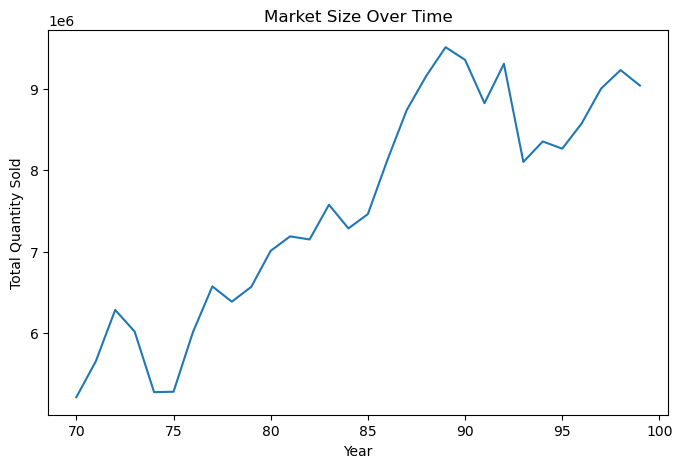

In [9]:
sales_by_year = cars.groupby("ye")["qu"].sum()

sales_by_year.plot(figsize=(8, 5))

plt.title("Market Size Over Time")
plt.xlabel("Year")
plt.ylabel("Total Quantity Sold")
plt.show()

### Business Interpretation

Vehicle sales increased substantially from 1970 to 1999, indicating long-term market expansion with short-term fluctuations. This provides a suitable setting for analyzing how demand responds to price, product attributes, and macroeconomic conditions over time.

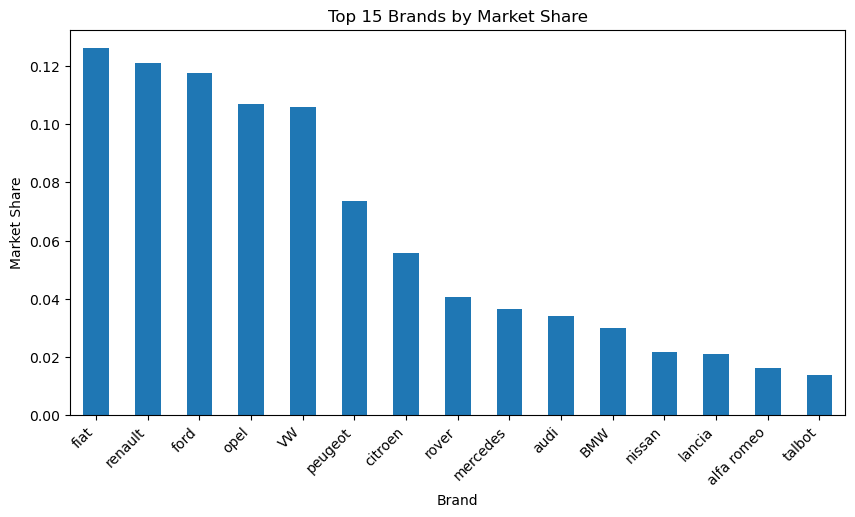

In [10]:
brand_sales = cars.groupby("brand")["qu"].sum().sort_values(ascending=False)

brand_share = (brand_sales / brand_sales.sum()).head(15)

brand_share.plot(kind="bar", figsize=(10, 5))

plt.title("Top 15 Brands by Market Share")
plt.xlabel("Brand")
plt.ylabel("Market Share")
plt.xticks(rotation=45, ha="right")
plt.show()

### Business Interpretation

Sales are concentrated among a small group of mass-market brands. This suggests that pricing strategy should account for brand scale and positioning rather than treating all manufacturers equally.

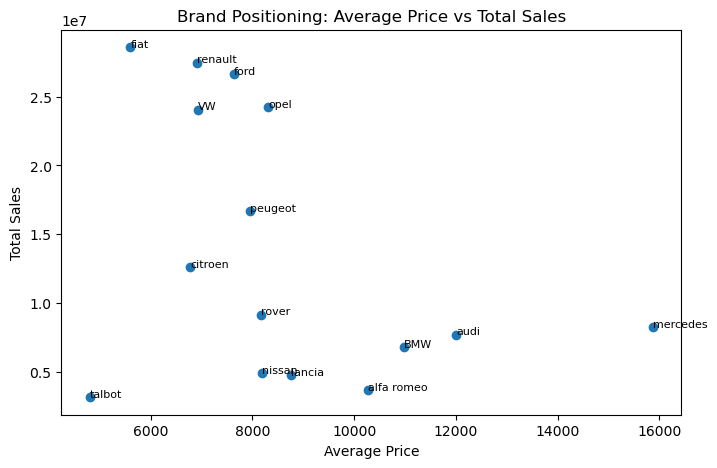

In [11]:
brand_positioning = (
    cars.groupby("brand")
    .agg(
        avg_price=("eurpr", "mean"),
        total_sales=("qu", "sum"),
        avg_hp=("hp", "mean")
    )
    .reset_index()
)

top_brands = brand_positioning.sort_values("total_sales", ascending=False).head(15)

plt.figure(figsize=(8, 5))
plt.scatter(top_brands["avg_price"], top_brands["total_sales"])

for _, row in top_brands.iterrows():
    plt.text(row["avg_price"], row["total_sales"], row["brand"], fontsize=8)

plt.title("Brand Positioning: Average Price vs Total Sales")
plt.xlabel("Average Price")
plt.ylabel("Total Sales")
plt.show()

### Business Interpretation

The market shows clear differences in brand positioning. High-volume brands tend to operate at lower average price points, while premium brands occupy higher-price, lower-volume positions. This supports the need for segment-specific pricing recommendations.

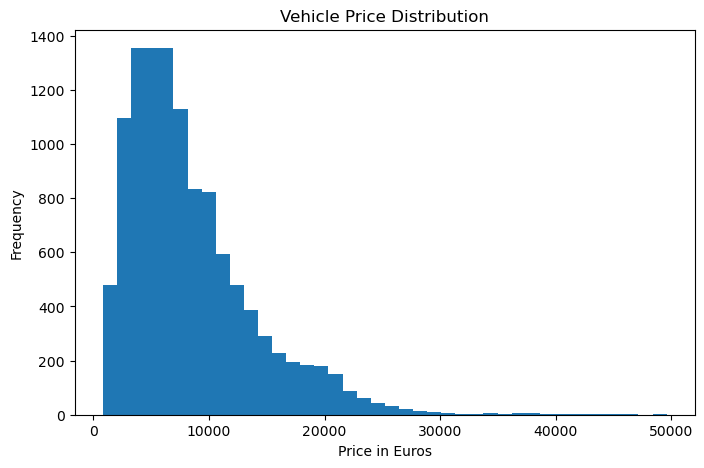

In [12]:
cars["eurpr"].plot(kind="hist", bins=40, figsize=(8, 5))

plt.title("Vehicle Price Distribution")
plt.xlabel("Price in Euros")
plt.ylabel("Frequency")
plt.show()

### Business Interpretation

The price distribution is right-skewed, indicating that most vehicles are positioned in lower-to-mid price ranges, while a smaller group of premium models occupies the high-price tail.

In [13]:
class_summary = (
    cars.groupby("cla")
    .agg(
        avg_price=("eurpr", "mean"),
        avg_sales=("qu", "mean"),
        total_sales=("qu", "sum"),
        models=("model", "nunique")
    )
    .reset_index()
)

class_summary

,cla,avg_price,avg_sales,total_sales,models
0,1,4781.818219,25976.818748,83411565,97
1,2,6881.756545,24409.845310,64539631,75
2,3,8869.967356,17985.046825,45322318,85
3,4,11207.208793,9943.706048,21209925,59
4,5,17590.227932,13051.073673,12046141,28


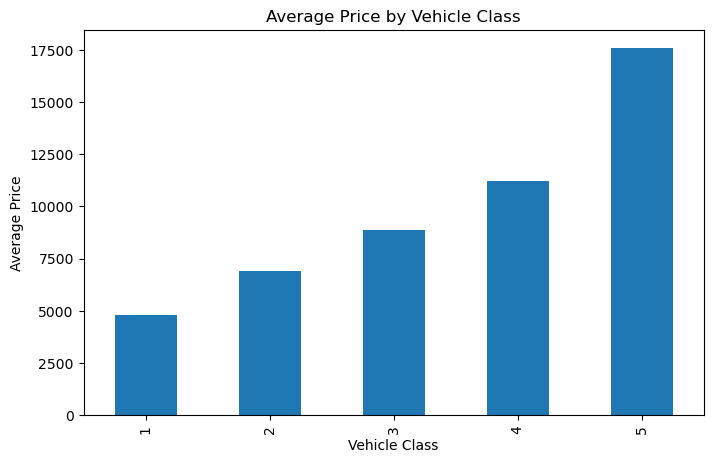

In [14]:
class_summary.set_index("cla")["avg_price"].plot(kind="bar", figsize=(8, 5))

plt.title("Average Price by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Average Price")
plt.show()

### Business Interpretation

Vehicle classes differ meaningfully in average price, suggesting that demand and pricing power may vary across product segments. Later demand models should control for class-level differences.